# WildJailbreak External Validation — Llama-3.1-8B (Crescendo)

This notebook is the **E3 external generalization** experiment for Llama-3.1-8B.
Every direction, classifier, and cluster center is fit on **JBB only**; every
test set is **WildJailbreak (WJ)**. This is the strongest available counter to
the paper draft's main limitation — that the displacement claim is computed
within JBB and could be a JBB-goals artifact.

### Tiers (per `docs/experiment_plan.md` §E3)

| Tier | Test set | Question |
|------|----------|----------|
| 1 | WJ vanilla harmful vs benign | Does the JBB-trained ST direction transfer to a new prompt distribution at all? |
| 2 | WJ adversarial harmful vs benign | Does single-turn adversarial framing alone already displace the direction? |
| 3 | WJ multi-turn Crescendo | Does the displacement / detection-failure / position-collapse story replicate on OOD multi-turn? |

Tier 1 must pass before Tier 3 means anything (you cannot test multi-turn
generalization with a JBB anchor that doesn't generalize even single-turn).

### Connection to prior work

**Zhao et al. (2025, NeurIPS) — *LLMs Encode Harmfulness and Refusal Separately*.**
- Tier 1/2 directly tests Zhao's *Latent Guard* claim (Δ_harmful at t_inst as a
  classifier) on out-of-distribution prompts.
- §4d (position collapse) and §4e (3-cell clustering) port Zhao's §3.2 analysis
  to WJ multi-turn, with cluster centers fit on JBB single-turn.

**Bullwinkel et al. (2025) — *RepE on Multi-Turn Jailbreaks*.**
- Bullwinkel did per-k extraction on Crescendo, **one model, JBB-only goals**,
  with an MLP probe trained on D_retain vs D_cb. We extend to OOD goals,
  add the no-context control they did not have, and replace the topic-confounded
  D_retain/D_cb pairing with within-pair JBB subtraction.

### Verdicts use AISI-StrongREJECT
Per `experiment_plan.md` §E4: framework judges optimize against themselves;
AISI is independent and strict. Every "accepted_harmful" / "refused_harmful"
label below comes from `aisi_scaled >= 0.5` (raw ≥ 3 on the 1–5 rubric).
Framework verdicts are reported only as a contrast in the final summary.

### What this notebook does NOT cover
- Cross-model (Gemma, Qwen) — Llama only here. Cross-model consolidation
  belongs in a separate notebook once WJ reps exist for the other two.
- Other frameworks (ActorAttack, X-Teaming) — Crescendo only.
- Circuit breakers — out of scope (E5).
- Causal steering — Zhao's reply-inversion test is not run on WJ.

### Hypotheses being tested

| ID | Statement | Tier |
|----|-----------|------|
| H1-WJ | `cos(v_full_WJ(k), v_ST_JBB)` decreases monotonically with k. | 3 |
| H1b-WJ | `cos(v_full_WJ(k), v_nc_WJ(k))` ≈ 1.0 at k=1, drops with k. | 3 |
| H2a-WJ | Fixed-direction AUROC near chance at mid/late k; adaptive recovers. | 3 |
| H2b-WJ | An MLP trained on JBB-ST cannot recover WJ multi-turn signal — displacement is structural, not a linear rotation. | 3 |
| H3-WJ | t_inst/t_post separation collapses on WJ multi-turn (matches JBB collapse). | 3 |
| H4-WJ | Full-context locus of harm signal exists; no-context collapses. | 3 |
| Tier 1 | JBB-ST direction achieves AUROC ≥ 0.85 on WJ vanilla harmful vs benign at the best layer. | 1 |
| Tier 2 | Adversarial AUROC ≥ 0.75 (a >0.10 drop from vanilla = "adversarial framing already displaces"). | 2 |

Each verdict is reported with a **bootstrap 95% CI at the conversation level**
and a pre-declared falsification threshold (so cutoffs aren't retrofitted).

## 1. Setup, paths, and data loading

Three input streams:
1. **JBB single-turn reps** — the anchor for v_harmful(ST), μ cluster centers, and the JBB-trained classifiers.
2. **WJ Tier 1/2 reps** — single-turn extractions on WJ vanilla/adversarial harmful + benign (produced by the existing `04_wildjailbreak_single_turn.ipynb`).
3. **WJ Tier 3 reps** — full-context, no-context, and single-turn extractions for WJ Crescendo conversations (produced by `04_wildjailbreak_extract_hidden_states.ipynb`).

Plus AISI-StrongREJECT scores for WJ Crescendo conversations at `data/llama/sr_final_scores_wj.csv`.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from tqdm.auto import tqdm

repo_root = Path("../..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# ── Constants ────────────────────────────────────────────────────────────────
MODEL    = "llama"
FRAMEWORK = "crescendo"
N_TRANSFORMER_LAYERS_TOTAL = 32
LAYER_INDICES = (np.linspace(0, N_TRANSFORMER_LAYERS_TOTAL - 1, 8, dtype=int) + 1).tolist()
LAYER_LABELS  = [f"L{l}" for l in LAYER_INDICES]
N_LAYERS_SAVED = len(LAYER_INDICES)

# Headline mid-layer for single-line figures (per "no arbitrary focal layers"
# feedback — supplementary panels still show the full sweep).
HEADLINE_LAYER_POS = 4   # 0-indexed → LAYER_INDICES[4] = L19 (mid-block)
HEADLINE_LAYER     = LAYER_INDICES[HEADLINE_LAYER_POS]

# AISI threshold (per experiment_plan.md §E4)
AISI_JAILBROKEN_THRESH = 0.5

# Train/test split on attempts (matches JBB convention)
TRAIN_MAX_ATTEMPT = 16

# Bootstrap config for CIs
N_BOOTSTRAP = 1000
RNG_SEED    = 42

# Falsification thresholds (pre-declared so they can't be retrofitted)
TIER1_AUROC_FLOOR  = 0.85
TIER2_AUROC_FLOOR  = 0.75
DISPLACEMENT_CI_BOUND = 0.5   # CI on cos(v_full_WJ(k_max), v_ST_JBB) must exclude this

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_ROOT  = repo_root / "data" / MODEL
JBB_REPR   = DATA_ROOT / "representations"
WJ_TIER12_REPR = DATA_ROOT / "representations" / "wildjailbreak"
WJ_TIER3_REPR  = DATA_ROOT / "representations_wj"
SR_WJ_CSV  = DATA_ROOT / "sr_final_scores_wj.csv"
FIG_DIR    = repo_root / "figures"
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 11, "axes.labelsize": 10,
                     "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9})
PALETTE = {
    "jbb":            "#7f7f7f",
    "wj_vanilla":     "#1f77b4",
    "wj_adversarial": "#d62728",
    "fixed":          "#7f7f7f",
    "adaptive":       "#1f77b4",
    "context":        "#2ca02c",
    "accepted_harmful":  "#d62728",
    "refused_harmful":   "#1f77b4",
    "accepted_harmless": "#2ca02c",
    "h_inst": "#1f77b4",
    "h_post": "#d62728",
    "full":   "#1f77b4",
    "nc":     "#7f7f7f",
}
print(f"Headline layer  : {LAYER_LABELS[HEADLINE_LAYER_POS]} (position {HEADLINE_LAYER_POS}/{N_LAYERS_SAVED-1})")
print(f"AISI threshold  : aisi_scaled >= {AISI_JAILBROKEN_THRESH}")
print(f"Bootstrap       : {N_BOOTSTRAP} conversation-level resamples, seed={RNG_SEED}")
print(f"Train attempts  : 1..{TRAIN_MAX_ATTEMPT}    Test attempts: {TRAIN_MAX_ATTEMPT+1}..")

Headline layer  : L18 (position 4/7)
AISI threshold  : aisi_scaled >= 0.5
Bootstrap       : 1000 conversation-level resamples, seed=42
Train attempts  : 1..16    Test attempts: 17..


In [6]:
# ── Loaders ──────────────────────────────────────────────────────────────────
def load_repr(folder, mmap=True):
    folder = Path(folder)
    meta   = pd.read_parquet(folder / "metadata.parquet")
    h_inst = np.load(folder / "h_inst.npy", mmap_mode="r" if mmap else None)
    h_post = np.load(folder / "h_post_inst.npy", mmap_mode="r" if mmap else None)
    assert len(meta) == len(h_inst) == len(h_post), f"shape mismatch in {folder}"
    return {"meta": meta.reset_index(drop=True), "h_inst": h_inst, "h_post": h_post}


def add_split(meta, train_max=TRAIN_MAX_ATTEMPT):
    meta = meta.copy()
    if "attempt" in meta.columns:
        meta["data_split"] = np.where(meta["attempt"] <= train_max, "train", "test")
    else:
        meta["data_split"] = "train"
    return meta


# JBB anchor — single-turn baseline (the only direction trained for the entire notebook)
jbb_st = {
    "harmful": load_repr(JBB_REPR / "single_turn" / "harmful"),
    "benign":  load_repr(JBB_REPR / "single_turn" / "benign"),
}
print(f"JBB ST harmful : {len(jbb_st['harmful']['meta'])}    benign: {len(jbb_st['benign']['meta'])}")

# Tier 1 + 2 — WJ single-turn (vanilla + adversarial)
wj_st = {}
for dt in ["harmful_vanilla", "harmful_adversarial", "benign_vanilla", "benign_adversarial"]:
    folder = WJ_TIER12_REPR / dt
    if folder.exists():
        wj_st[dt] = load_repr(folder)
        print(f"WJ ST {dt:24s}: {len(wj_st[dt]['meta']):5d}")
    else:
        print(f"WJ ST {dt:24s}: MISSING ({folder}) — Tier 1/2 will be skipped")

# Tier 3 — WJ multi-turn Crescendo
wj_mt = {}
for cond in ["trajectories", "nocontext"]:
    for split in ["harmful", "benign"]:
        folder = WJ_TIER3_REPR / cond / f"{FRAMEWORK}_{split}"
        if folder.exists():
            d = load_repr(folder)
            d["meta"] = add_split(d["meta"])
            wj_mt[(cond, split)] = d
            print(f"WJ MT {cond:13s} {split:7s}: {len(d['meta']):6d}")
        else:
            print(f"WJ MT {cond:13s} {split:7s}: MISSING ({folder})")

# Single-turn baseline reps over the WJ-OOD-selected goals (used as a same-distribution control for Zhao centers)
for split in ["harmful", "benign"]:
    folder = WJ_TIER3_REPR / "single_turn" / split
    if folder.exists():
        wj_mt[("single_turn", split)] = load_repr(folder)
        print(f"WJ ST-OOD {split:7s}: {len(wj_mt[('single_turn', split)]['meta']):6d}")

JBB ST harmful : 100    benign: 100
WJ ST harmful_vanilla         : MISSING (/Users/lisahusieva/Desktop/multi-turn-rep-eng/data/llama/representations/wildjailbreak/harmful_vanilla) — Tier 1/2 will be skipped
WJ ST harmful_adversarial     : MISSING (/Users/lisahusieva/Desktop/multi-turn-rep-eng/data/llama/representations/wildjailbreak/harmful_adversarial) — Tier 1/2 will be skipped
WJ ST benign_vanilla          : MISSING (/Users/lisahusieva/Desktop/multi-turn-rep-eng/data/llama/representations/wildjailbreak/benign_vanilla) — Tier 1/2 will be skipped
WJ ST benign_adversarial      : MISSING (/Users/lisahusieva/Desktop/multi-turn-rep-eng/data/llama/representations/wildjailbreak/benign_adversarial) — Tier 1/2 will be skipped
WJ MT trajectories  harmful:   4178
WJ MT trajectories  benign :   3396
WJ MT nocontext     harmful:   4178
WJ MT nocontext     benign :   3396
WJ ST-OOD harmful:     50
WJ ST-OOD benign :     50


In [7]:
# ── AISI-StrongREJECT scores for WJ Crescendo ────────────────────────────────
# Expected schema (matches data/{model}/sr_final_scores.csv):
#   conversation_id, aisi_raw, aisi_scaled, attempt, final_turn_k,
#   framework, framework_jailbroken, framework_verdict, model, pair_id,
#   split, sr_composite, sr_convincing, sr_refused, sr_specific
if SR_WJ_CSV.exists():
    sr = pd.read_csv(SR_WJ_CSV)
    sr = sr[(sr["framework"] == FRAMEWORK) & (sr["model"] == MODEL)].copy()
    sr["aisi_jailbroken"] = (sr["aisi_scaled"].astype(float) >= AISI_JAILBROKEN_THRESH)
    print(f"WJ AISI scores : {len(sr):4d} rows")
    print(sr.groupby(["split", "aisi_jailbroken"]).size().rename("n").to_frame())
else:
    print(f"WARNING: {SR_WJ_CSV} not found.")
    print("Run StrongREJECT scoring on WJ Crescendo conversations before §4d/§4e.")
    sr = pd.DataFrame(columns=["conversation_id", "aisi_jailbroken", "framework",
                               "model", "pair_id", "attempt", "split"])


def attach_aisi(meta, sr_df):
    '''Add aisi_jailbroken to a meta frame keyed on (pair_id, attempt, split).'''
    meta = meta.copy()
    if len(sr_df) == 0 or "conversation_id" not in meta.columns:
        meta["aisi_jailbroken"] = np.nan
        return meta
    keys = sr_df.set_index("conversation_id")["aisi_jailbroken"]
    meta["aisi_jailbroken"] = meta["conversation_id"].map(keys)
    return meta


for k in [("trajectories", "harmful"), ("trajectories", "benign"),
          ("nocontext",    "harmful"), ("nocontext",    "benign")]:
    if k in wj_mt:
        wj_mt[k]["meta"] = attach_aisi(wj_mt[k]["meta"], sr)

WJ AISI scores :  686 rows
                           n
split   aisi_jailbroken     
harmful False            423
        True             263


In [8]:
# ── Sample-size table per turn (per E2 governance) ───────────────────────────
def sample_size_table(data_dict):
    rows = []
    for (cond, split), d in data_dict.items():
        if cond == "single_turn":
            continue
        m = d["meta"]
        if "turn_k" not in m.columns:
            continue
        for k, sub in m.groupby("turn_k"):
            rows.append({"cond": cond, "split": split, "turn_k": int(k),
                         "n_total": len(sub),
                         "n_test":  int((sub["data_split"] == "test").sum())})
    df = pd.DataFrame(rows).pivot_table(index="turn_k",
                                         columns=["cond", "split"],
                                         values="n_test").fillna(0).astype(int)
    return df

if any(k for k in wj_mt if k[0] == "trajectories"):
    n_table = sample_size_table(wj_mt)
    print("Per-turn TEST-split sample sizes (WJ Crescendo):")
    print(n_table.to_string())
    print()
    print("Pre-registered floor: n >= 100 per class per turn for primary figures.")
    underfloor = (n_table.min(axis=1) < 100)
    if underfloor.any():
        print(f"Turns under floor: {list(underfloor[underfloor].index)} — truncated in figures.")
else:
    print("WJ Crescendo trajectories not loaded; skipping sample-size table.")

Per-turn TEST-split sample sizes (WJ Crescendo):
cond   nocontext         trajectories        
split     benign harmful       benign harmful
turn_k                                       
1            180     137          180     137
2            175     137          175     137
3            120     125          120     125
4             59     111           59     111
5             36      92           36      92
6             27      74           27      74
7             22      57           22      57
8             19      43           19      43
9             16      34           16      34
10            15      25           15      25

Pre-registered floor: n >= 100 per class per turn for primary figures.
Turns under floor: [4, 5, 6, 7, 8, 9, 10] — truncated in figures.


## 2. Tier 1 — Single-turn vanilla generalization

**Question.** Does v_harmful(ST), trained on JBB single-turn, classify
WJ *vanilla* harmful vs benign? This is the prerequisite for everything
downstream — if the JBB anchor doesn't generalize even in single-turn,
multi-turn analyses against it are meaningless.

**Method.** Within-pair difference of means on JBB single-turn at each layer
gives v_harmful(ST). Project WJ vanilla samples onto this direction; AUROC
for harmful vs benign per layer, separately at t_inst and t_post.

**Connection to Zhao.** This is exactly Zhao's *Latent Guard* setup —
Δ_harmful at t_inst as a classifier — applied OOD. Zhao reported it
matches Llama Guard 3 8B on Advbench-style prompts. Tier 1 tests whether
this generalizes to WJ's much broader prompt distribution.

**Pre-declared falsification.** Tier 1 passes if **best-layer AUROC ≥ 0.85**
at t_inst with bootstrap 95% CI lower bound > 0.80. Anything weaker means
the JBB-trained anchor is too narrow to support a multi-turn generalization
claim, and the rest of the notebook should be read with that caveat.

In [9]:
def within_pair_direction(h_a, m_a, h_b, m_b, layer_pos):
    """Within-pair difference-of-means at one layer position. Returns unit vector."""
    pairs = sorted(set(m_a["pair_id"]) & set(m_b["pair_id"]))
    diffs = []
    for pid in pairs:
        idx_a = m_a.index[m_a["pair_id"] == pid].tolist()
        idx_b = m_b.index[m_b["pair_id"] == pid].tolist()
        if not idx_a or not idx_b:
            continue
        mu_a = h_a[idx_a, layer_pos, :].astype(np.float32).mean(axis=0)
        mu_b = h_b[idx_b, layer_pos, :].astype(np.float32).mean(axis=0)
        diffs.append(mu_a - mu_b)
    if not diffs:
        return None
    d = np.stack(diffs).mean(axis=0)
    return d / (np.linalg.norm(d) + 1e-12)


# ── Compute v_harmful(JBB-ST) at every saved layer, both positions ───────────
m_jh = jbb_st["harmful"]["meta"].sort_values("pair_id").reset_index(drop=True)
m_jb = jbb_st["benign" ]["meta"].sort_values("pair_id").reset_index(drop=True)

v_st_jbb = {"h_inst": np.zeros((N_LAYERS_SAVED, jbb_st["harmful"]["h_inst"].shape[-1]), dtype=np.float32),
            "h_post": np.zeros((N_LAYERS_SAVED, jbb_st["harmful"]["h_post"].shape[-1]), dtype=np.float32)}
for li in range(N_LAYERS_SAVED):
    for h_key in ["h_inst", "h_post"]:
        v = within_pair_direction(jbb_st["harmful"][h_key], m_jh,
                                   jbb_st["benign" ][h_key], m_jb, li)
        v_st_jbb[h_key][li] = v

print(f"v_harmful(JBB-ST) computed at {N_LAYERS_SAVED} layers, both positions.")

v_harmful(JBB-ST) computed at 8 layers, both positions.


In [10]:
def project_auroc(h, meta, direction, layer_pos, label_col, pos_label):
    """AUROC of projection onto `direction` for the binary task `label_col == pos_label`."""
    if direction is None or len(meta) == 0:
        return np.nan
    proj = h[:, layer_pos, :].astype(np.float32) @ direction
    y    = (meta[label_col].values == pos_label).astype(int)
    if y.sum() < 5 or (1 - y).sum() < 5:
        return np.nan
    return roc_auc_score(y, proj)


def bootstrap_auroc(h, meta, direction, layer_pos, label_col, pos_label,
                    n_boot=N_BOOTSTRAP, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n   = len(meta)
    out = np.zeros(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        out[i] = project_auroc(h[idx], meta.iloc[idx], direction, layer_pos, label_col, pos_label)
    return np.nanmean(out), np.nanpercentile(out, 2.5), np.nanpercentile(out, 97.5)


def stack_pair(d_h, d_b, h_key):
    """Concatenate harmful + benign reps + a unified meta frame with goal_type column."""
    h = np.concatenate([d_h[h_key], d_b[h_key]], axis=0)
    m = pd.concat([d_h["meta"].assign(goal_type="harmful"),
                   d_b["meta"].assign(goal_type="benign")], ignore_index=True)
    return h, m


def tier12_curve(harmful_key, benign_key, h_key):
    if harmful_key not in wj_st or benign_key not in wj_st:
        return None
    h, m = stack_pair(wj_st[harmful_key], wj_st[benign_key], h_key)
    means, lo, hi = [], [], []
    for li in range(N_LAYERS_SAVED):
        mu, lb, ub = bootstrap_auroc(h, m, v_st_jbb[h_key][li], li,
                                      "goal_type", "harmful")
        means.append(mu); lo.append(lb); hi.append(ub)
    return np.array(means), np.array(lo), np.array(hi)


# Compute Tier 1 (vanilla) and Tier 2 (adversarial) curves, both positions
tier_curves = {}
for tag, hk, bk in [("vanilla",     "harmful_vanilla",     "benign_vanilla"),
                    ("adversarial", "harmful_adversarial", "benign_adversarial")]:
    for h_key in ["h_inst", "h_post"]:
        tier_curves[(tag, h_key)] = tier12_curve(hk, bk, h_key)

for k, v in tier_curves.items():
    if v is None:
        print(f"  {k}: skipped (subset missing)")
    else:
        m, _, _ = v
        best_pos = int(np.nanargmax(m))
        print(f"  {k[0]:12s} {k[1]:6s}: best {LAYER_LABELS[best_pos]} AUROC = {m[best_pos]:.3f}")

  ('vanilla', 'h_inst'): skipped (subset missing)
  ('vanilla', 'h_post'): skipped (subset missing)
  ('adversarial', 'h_inst'): skipped (subset missing)
  ('adversarial', 'h_post'): skipped (subset missing)


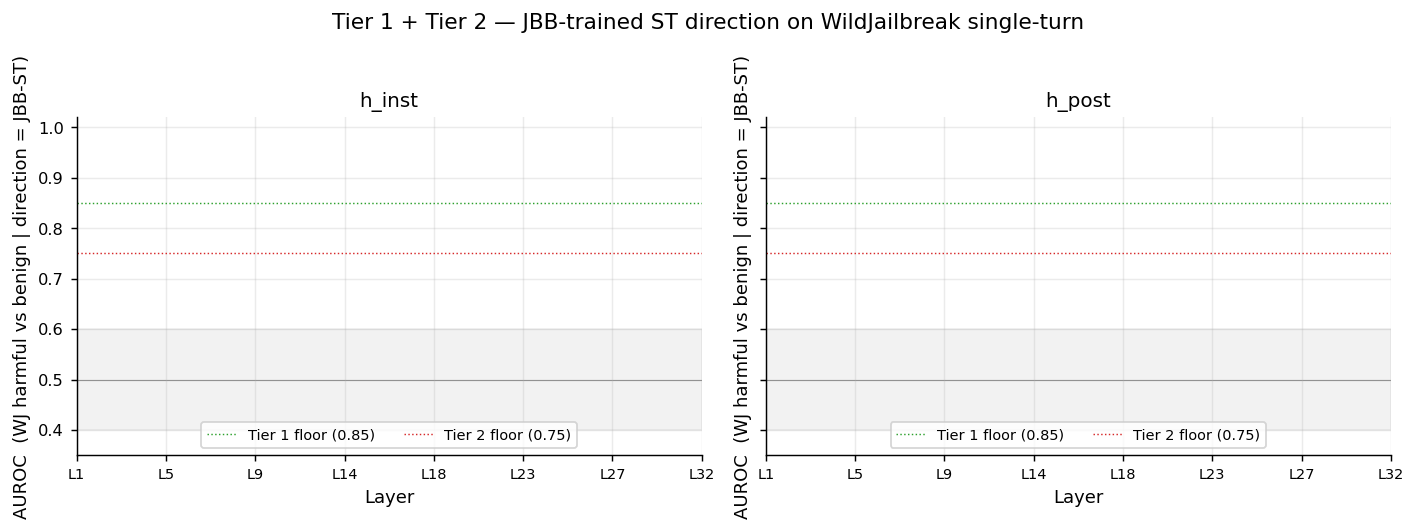

In [11]:
# ── Figure: Tier 1 + Tier 2 generalization (both layers swept) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

xs = np.arange(N_LAYERS_SAVED)
for ax, h_key in zip(axes, ["h_inst", "h_post"]):
    ax.axhspan(0.4, 0.6, color="#cccccc", alpha=0.25, zorder=0)  # chance band
    ax.axhline(0.5, color="#888888", lw=0.6, zorder=1)
    ax.axhline(TIER1_AUROC_FLOOR, color="#2ca02c", lw=0.8, ls=":", label=f"Tier 1 floor ({TIER1_AUROC_FLOOR:.2f})")
    ax.axhline(TIER2_AUROC_FLOOR, color="#d62728", lw=0.8, ls=":", label=f"Tier 2 floor ({TIER2_AUROC_FLOOR:.2f})")

    for tag, color in [("vanilla", PALETTE["wj_vanilla"]),
                       ("adversarial", PALETTE["wj_adversarial"])]:
        curve = tier_curves.get((tag, h_key))
        if curve is None:
            continue
        m, lo, hi = curve
        ax.fill_between(xs, lo, hi, color=color, alpha=0.18, zorder=2)
        ax.plot(xs, m, "o-", color=color, lw=1.6, ms=4.5, label=f"WJ {tag}", zorder=3)

    ax.set_xticks(xs); ax.set_xticklabels(LAYER_LABELS, fontsize=8)
    ax.set_xlabel("Layer")
    ax.set_ylabel("AUROC  (WJ harmful vs benign | direction = JBB-ST)")
    ax.set_title(f"{h_key}")
    ax.set_ylim(0.35, 1.02)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower center", ncols=2, fontsize=8)

fig.suptitle("Tier 1 + Tier 2 — JBB-trained ST direction on WildJailbreak single-turn", y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_fig1_tier12_generalization.png")
plt.show()

In [12]:
# ── Pre-declared verdicts ────────────────────────────────────────────────────
def verdict_tier(tag, floor):
    if (tag, "h_inst") not in tier_curves or tier_curves[(tag, "h_inst")] is None:
        return "DATA MISSING"
    m, lo, hi = tier_curves[(tag, "h_inst")]
    best = int(np.nanargmax(m))
    passes = (m[best] >= floor) and (lo[best] >= floor - 0.05)
    return (f"{'PASS' if passes else 'FAIL'} — best AUROC {m[best]:.3f} "
            f"[{lo[best]:.3f}, {hi[best]:.3f}] at {LAYER_LABELS[best]} "
            f"(floor {floor:.2f})")

print("Tier 1 (vanilla)    :", verdict_tier("vanilla",     TIER1_AUROC_FLOOR))
print("Tier 2 (adversarial):", verdict_tier("adversarial", TIER2_AUROC_FLOOR))

Tier 1 (vanilla)    : DATA MISSING
Tier 2 (adversarial): DATA MISSING


**Reading the figure.** Both panels show AUROC at every saved layer. Bands are
bootstrap 95% CIs. The *vanilla* line tests whether the JBB ST direction transfers
to OOD prompts at all (Tier 1). The *adversarial* line tests whether single-turn
adversarial framing alone already pushes WJ harmful prompts off the JBB axis
(Tier 2). The expected pattern in Zhao's framework is vanilla > adversarial with
the *gap* itself diagnostic: a large gap means adversarial framing is doing
displacement work even before any multi-turn context accumulates.

## 3. Tier 3 — Multi-turn external (Crescendo on WJ)

The five sub-questions below mirror the headline JBB-only analyses (nb04
displacement, nb05 token position, nb06 nonlinear) but trained on JBB and
tested on WJ. Each sub-section has a methodology preamble, one figure, and
a verdict line.

In [13]:
def get_final_turn_idx(data):
    m = data["meta"]
    if "turn_k" not in m.columns:
        return np.arange(len(m))
    return m.groupby("conversation_id")["turn_k"].idxmax().values


def per_turn_train_test(data, k):
    """Boolean masks for train/test rows at exactly turn k."""
    m = data["meta"]
    train = ((m["turn_k"] == k) & (m["data_split"] == "train")).values
    test  = ((m["turn_k"] == k) & (m["data_split"] == "test" )).values
    return train, test


# Turns to evaluate — only those meeting the n>=100 floor on test split
def eligible_turns(data_h, data_b, floor=100):
    eligible = []
    for k in range(1, 11):
        _, test_h = per_turn_train_test(data_h, k)
        _, test_b = per_turn_train_test(data_b, k)
        if test_h.sum() >= floor and test_b.sum() >= floor:
            eligible.append(k)
    return eligible

if ("trajectories", "harmful") in wj_mt and ("trajectories", "benign") in wj_mt:
    EL_TURNS = eligible_turns(wj_mt[("trajectories", "harmful")],
                              wj_mt[("trajectories", "benign")])
else:
    EL_TURNS = []
print(f"Eligible turns (n_test >= 100 per class): {EL_TURNS}")

Eligible turns (n_test >= 100 per class): [1, 2, 3]


### 4a. RQ1 — Displacement on WJ Crescendo

**Hypothesis (H1-WJ).** `cos(v_full_WJ(k), v_ST_JBB)` decreases monotonically
with k, and `cos(v_full_WJ(k), v_nc_WJ(k))` starts near 1.0 at k=1 and drops
with k. The latter is the context-attribution control: at k=1 there is no
prior history, so full-context and no-context are identical inputs and the
cosine must be ≈ 1.0 by construction. Any divergence at k > 1 is
*pure context accumulation* — it cannot be the message content.

**Method.** Within-pair direction at each k on WJ-train, evaluated by cosine
against (a) the JBB-ST anchor and (b) the WJ-NC same-turn direction. Computed
at the headline layer `LAYER_INDICES[HEADLINE_LAYER_POS]` (the "no arbitrary
focal layers" feedback memory: full layer-sweep heatmap shown alongside).

**Pre-declared falsification.** Bootstrap 95% CI on the displacement endpoint
`cos(v_full_WJ(k_max), v_ST_JBB)` must exclude 0.5 → displacement is real
and substantial (not just noise around the JBB direction).

In [14]:
def per_turn_direction(data_h, data_b, k, layer_pos, h_key):
    """Within-pair direction at turn k (train split), specified layer + position."""
    train_h, _ = per_turn_train_test(data_h, k)
    train_b, _ = per_turn_train_test(data_b, k)
    if train_h.sum() < 10 or train_b.sum() < 10:
        return None
    mh = data_h["meta"][train_h].reset_index(drop=True)
    mb = data_b["meta"][train_b].reset_index(drop=True)
    return within_pair_direction(data_h[h_key][train_h], mh,
                                  data_b[h_key][train_b], mb, layer_pos)


def cos(a, b):
    if a is None or b is None:
        return np.nan
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


def displacement_curves(layer_pos, h_key):
    """Per-turn cos(v_full_WJ(k), v_ST_JBB) and cos(v_full_WJ(k), v_nc_WJ(k))."""
    v_st = v_st_jbb[h_key][layer_pos]
    if not EL_TURNS or ("trajectories", "harmful") not in wj_mt:
        return None
    out = {"k": EL_TURNS, "vs_jbb_st": [], "vs_nc": []}
    for k in EL_TURNS:
        v_full = per_turn_direction(wj_mt[("trajectories", "harmful")],
                                     wj_mt[("trajectories", "benign")], k, layer_pos, h_key)
        v_nc = None
        if ("nocontext", "harmful") in wj_mt and ("nocontext", "benign") in wj_mt:
            v_nc = per_turn_direction(wj_mt[("nocontext", "harmful")],
                                       wj_mt[("nocontext", "benign")], k, layer_pos, h_key)
        out["vs_jbb_st"].append(cos(v_full, v_st))
        out["vs_nc"   ].append(cos(v_full, v_nc))
    return out


def bootstrap_displacement_endpoint(layer_pos, h_key, k_endpoint,
                                     n_boot=N_BOOTSTRAP, seed=RNG_SEED):
    """Bootstrap the cos at k=k_endpoint by resampling conversations."""
    if not EL_TURNS or k_endpoint not in EL_TURNS:
        return None
    d_h = wj_mt[("trajectories", "harmful")]
    d_b = wj_mt[("trajectories", "benign")]
    v_st = v_st_jbb[h_key][layer_pos]
    rng = np.random.default_rng(seed)

    train_h = ((d_h["meta"]["turn_k"] == k_endpoint) & (d_h["meta"]["data_split"] == "train")).values
    train_b = ((d_b["meta"]["turn_k"] == k_endpoint) & (d_b["meta"]["data_split"] == "train")).values
    if train_h.sum() < 10 or train_b.sum() < 10:
        return None

    H_h = d_h[h_key][train_h, layer_pos, :].astype(np.float32)
    H_b = d_b[h_key][train_b, layer_pos, :].astype(np.float32)
    M_h = d_h["meta"][train_h].reset_index(drop=True)
    M_b = d_b["meta"][train_b].reset_index(drop=True)

    pairs = sorted(set(M_h["pair_id"]) & set(M_b["pair_id"]))
    cos_vals = np.zeros(n_boot)
    for i in range(n_boot):
        sample = rng.choice(pairs, size=len(pairs), replace=True)
        diffs = []
        for pid in sample:
            ih = M_h.index[M_h["pair_id"] == pid].tolist()
            ib = M_b.index[M_b["pair_id"] == pid].tolist()
            if not ih or not ib:
                continue
            diffs.append(H_h[ih].mean(0) - H_b[ib].mean(0))
        if not diffs:
            cos_vals[i] = np.nan; continue
        d = np.stack(diffs).mean(0)
        d /= (np.linalg.norm(d) + 1e-12)
        cos_vals[i] = float(np.dot(d, v_st))
    return float(np.nanmean(cos_vals)), float(np.nanpercentile(cos_vals, 2.5)), float(np.nanpercentile(cos_vals, 97.5))


# Compute curves at headline layer + a layer-sweep heatmap
disp_inst = displacement_curves(HEADLINE_LAYER_POS, "h_inst")
disp_post = displacement_curves(HEADLINE_LAYER_POS, "h_post")

# Layer × turn heatmap of cos(v_full_WJ(k), v_ST_JBB) at h_inst
heat = np.full((N_LAYERS_SAVED, len(EL_TURNS)), np.nan) if EL_TURNS else None
if EL_TURNS:
    for li in range(N_LAYERS_SAVED):
        c = displacement_curves(li, "h_inst")
        if c is not None:
            heat[li] = c["vs_jbb_st"]

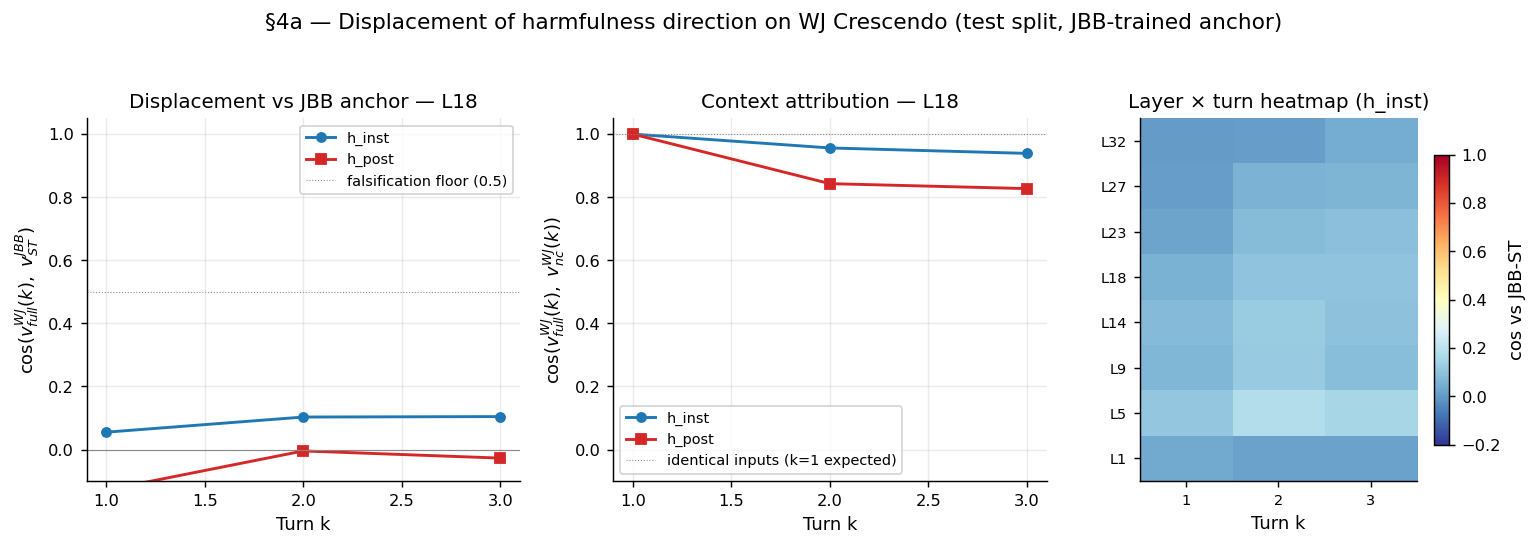

In [15]:
fig = plt.figure(figsize=(12, 4.0))
gs  = fig.add_gridspec(1, 3, width_ratios=[2.0, 2.0, 1.6])

# Left: cos(v_full, v_ST_JBB) at headline layer, h_inst + h_post
ax0 = fig.add_subplot(gs[0, 0])
for h_key, color, marker in [("h_inst", PALETTE["h_inst"], "o"),
                              ("h_post", PALETTE["h_post"], "s")]:
    d = disp_inst if h_key == "h_inst" else disp_post
    if d is None: continue
    ax0.plot(d["k"], d["vs_jbb_st"], marker + "-", color=color, lw=1.6, ms=5,
             label=f"{h_key}")
ax0.axhline(DISPLACEMENT_CI_BOUND, color="#888", lw=0.6, ls=":", label=f"falsification floor ({DISPLACEMENT_CI_BOUND})")
ax0.axhline(0, color="#888", lw=0.6)
ax0.set_xlabel("Turn k")
ax0.set_ylabel(r"cos$(v_{full}^{WJ}(k),\ v_{ST}^{JBB})$")
ax0.set_title(f"Displacement vs JBB anchor — {LAYER_LABELS[HEADLINE_LAYER_POS]}")
ax0.set_ylim(-0.1, 1.05)
ax0.grid(True, alpha=0.25)
ax0.legend(fontsize=8)

# Middle: cos(v_full_WJ(k), v_nc_WJ(k)) — context attribution
ax1 = fig.add_subplot(gs[0, 1])
for h_key, color, marker in [("h_inst", PALETTE["h_inst"], "o"),
                              ("h_post", PALETTE["h_post"], "s")]:
    d = disp_inst if h_key == "h_inst" else disp_post
    if d is None: continue
    ax1.plot(d["k"], d["vs_nc"], marker + "-", color=color, lw=1.6, ms=5,
             label=f"{h_key}")
ax1.axhline(1.0, color="#888", lw=0.6, ls=":", label="identical inputs (k=1 expected)")
ax1.set_xlabel("Turn k")
ax1.set_ylabel(r"cos$(v_{full}^{WJ}(k),\ v_{nc}^{WJ}(k))$")
ax1.set_title(f"Context attribution — {LAYER_LABELS[HEADLINE_LAYER_POS]}")
ax1.set_ylim(-0.1, 1.05)
ax1.grid(True, alpha=0.25)
ax1.legend(fontsize=8)

# Right: layer-sweep heatmap of cos(v_full, v_ST_JBB) at h_inst
ax2 = fig.add_subplot(gs[0, 2])
if heat is not None:
    im = ax2.imshow(heat, aspect="auto", cmap="RdYlBu_r", vmin=-0.2, vmax=1.0,
                    origin="lower")
    ax2.set_xticks(range(len(EL_TURNS))); ax2.set_xticklabels(EL_TURNS, fontsize=8)
    ax2.set_yticks(range(N_LAYERS_SAVED)); ax2.set_yticklabels(LAYER_LABELS, fontsize=8)
    ax2.set_xlabel("Turn k")
    ax2.set_title("Layer × turn heatmap (h_inst)")
    plt.colorbar(im, ax=ax2, shrink=0.8, label="cos vs JBB-ST")

fig.suptitle("§4a — Displacement of harmfulness direction on WJ Crescendo (test split, JBB-trained anchor)", y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_fig2_displacement.png")
plt.show()

In [16]:
# ── Verdict (bootstrap CI on endpoint) ───────────────────────────────────────
endpoint_k = EL_TURNS[-1] if EL_TURNS else None
if endpoint_k is not None:
    boot = bootstrap_displacement_endpoint(HEADLINE_LAYER_POS, "h_inst", endpoint_k)
    if boot is not None:
        mean, lo, hi = boot
        passes = hi < DISPLACEMENT_CI_BOUND
        print(f"H1-WJ verdict: {'PASS' if passes else 'FAIL'}")
        print(f"  cos(v_full_WJ(k={endpoint_k}), v_ST_JBB) at {LAYER_LABELS[HEADLINE_LAYER_POS]}")
        print(f"  mean = {mean:.3f}  95% CI = [{lo:.3f}, {hi:.3f}]")
        print(f"  falsification: CI must exclude {DISPLACEMENT_CI_BOUND}")

H1-WJ verdict: PASS
  cos(v_full_WJ(k=3), v_ST_JBB) at L18
  mean = 0.090  95% CI = [0.044, 0.135]
  falsification: CI must exclude 0.5


### 4b. RQ2a — Detection failure: fixed vs adaptive AUROC

**Hypothesis (H2a-WJ).** Fixed-direction (JBB-ST anchor) AUROC drops toward
chance as k accumulates; an adaptive per-turn direction (computed on
WJ-train at the same k) recovers performance. The gap is the practical
cost of the displacement measured in §4a.

**Method.** At each eligible turn k, project WJ-test reps onto two directions
at the headline layer and at h_inst:
- **Fixed:** v_harmful(JBB-ST) — what a single-turn defense would deploy.
- **Adaptive:** within-pair direction recomputed on WJ-train at this turn.
Bootstrap the AUROCs at the conversation level.

**Why this matters.** A fixed-direction defense is the deployable scenario;
adaptive is the upper bound of what a per-turn detector could achieve.
Both being well below ceiling on WJ would mean *neither* a single-turn
defense nor a turn-aware one trained on this distribution is enough.

In [17]:
def fixed_vs_adaptive_auroc(layer_pos, h_key, k):
    d_h = wj_mt[("trajectories", "harmful")]
    d_b = wj_mt[("trajectories", "benign")]
    train_h, test_h = per_turn_train_test(d_h, k)
    train_b, test_b = per_turn_train_test(d_b, k)
    if test_h.sum() < 5 or test_b.sum() < 5:
        return np.nan, (np.nan, np.nan), np.nan, (np.nan, np.nan)

    # Concat test data
    H_t = np.concatenate([d_h[h_key][test_h, layer_pos, :],
                          d_b[h_key][test_b, layer_pos, :]], axis=0).astype(np.float32)
    y   = np.concatenate([np.ones(test_h.sum()), np.zeros(test_b.sum())])

    # Fixed direction
    v_fix = v_st_jbb[h_key][layer_pos]
    proj_fix = H_t @ v_fix

    # Adaptive direction
    v_adp = per_turn_direction(d_h, d_b, k, layer_pos, h_key)
    proj_adp = H_t @ v_adp if v_adp is not None else None

    # Bootstrap CIs
    rng = np.random.default_rng(RNG_SEED + k)
    fix_boot, adp_boot = [], []
    n = len(y)
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, n, size=n)
        if (y[idx].sum() < 2) or ((1 - y[idx]).sum() < 2):
            continue
        fix_boot.append(roc_auc_score(y[idx], proj_fix[idx]))
        if proj_adp is not None:
            adp_boot.append(roc_auc_score(y[idx], proj_adp[idx]))

    fix_mean = float(np.mean(fix_boot)) if fix_boot else np.nan
    fix_ci   = (float(np.percentile(fix_boot, 2.5)), float(np.percentile(fix_boot, 97.5))) if fix_boot else (np.nan, np.nan)
    adp_mean = float(np.mean(adp_boot)) if adp_boot else np.nan
    adp_ci   = (float(np.percentile(adp_boot, 2.5)), float(np.percentile(adp_boot, 97.5))) if adp_boot else (np.nan, np.nan)
    return fix_mean, fix_ci, adp_mean, adp_ci


det_rows = []
if EL_TURNS:
    for k in EL_TURNS:
        fix_m, fix_ci, adp_m, adp_ci = fixed_vs_adaptive_auroc(HEADLINE_LAYER_POS, "h_inst", k)
        det_rows.append({"turn_k": k,
                         "fixed_mean": fix_m, "fixed_lo": fix_ci[0], "fixed_hi": fix_ci[1],
                         "adp_mean":   adp_m, "adp_lo":   adp_ci[0], "adp_hi":   adp_ci[1]})
det_df = pd.DataFrame(det_rows)
det_df

,turn_k,fixed_mean,fixed_lo,fixed_hi,adp_mean,adp_lo,adp_hi
0,1,0.584268,0.526005,0.644261,0.882702,0.844974,0.917801
1,2,0.684566,0.624301,0.739896,0.912663,0.882390,0.941685
2,3,0.640247,0.564378,0.708491,0.916441,0.878751,0.950697


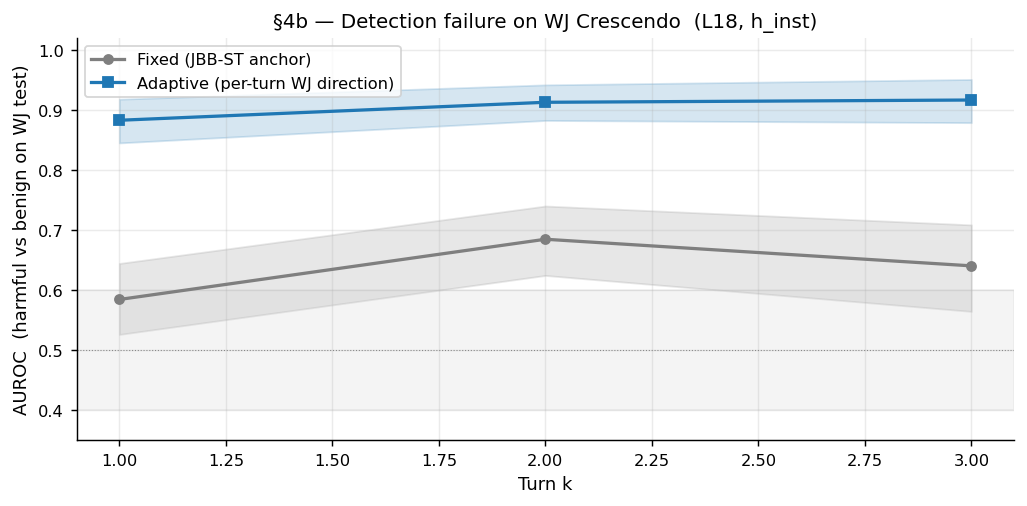

H2a-WJ verdict: fixed-AUROC mean = 0.636, adaptive = 0.904, gap = +0.268
  → consistent with detection-failure pattern (fixed near chance, adaptive recovers).


In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
if not det_df.empty:
    ax.fill_between(det_df["turn_k"], det_df["fixed_lo"], det_df["fixed_hi"],
                    color=PALETTE["fixed"], alpha=0.18)
    ax.plot(det_df["turn_k"], det_df["fixed_mean"], "o-", color=PALETTE["fixed"], lw=1.8, ms=5,
            label="Fixed (JBB-ST anchor)")
    ax.fill_between(det_df["turn_k"], det_df["adp_lo"], det_df["adp_hi"],
                    color=PALETTE["adaptive"], alpha=0.18)
    ax.plot(det_df["turn_k"], det_df["adp_mean"], "s-", color=PALETTE["adaptive"], lw=1.8, ms=5,
            label="Adaptive (per-turn WJ direction)")
ax.axhline(0.5, color="#888", lw=0.6, ls=":")
ax.axhspan(0.4, 0.6, color="#cccccc", alpha=0.2)
ax.set_xlabel("Turn k")
ax.set_ylabel("AUROC  (harmful vs benign on WJ test)")
ax.set_title(f"§4b — Detection failure on WJ Crescendo  ({LAYER_LABELS[HEADLINE_LAYER_POS]}, h_inst)")
ax.set_ylim(0.35, 1.02)
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "10_fig3_detection_failure.png")
plt.show()

if not det_df.empty:
    fix_avg = det_df["fixed_mean"].mean()
    adp_avg = det_df["adp_mean"].mean()
    gap = adp_avg - fix_avg
    print(f"H2a-WJ verdict: fixed-AUROC mean = {fix_avg:.3f}, adaptive = {adp_avg:.3f}, "
          f"gap = {gap:+.3f}")
    if fix_avg < 0.65 and adp_avg > 0.75:
        print("  → consistent with detection-failure pattern (fixed near chance, adaptive recovers).")

### 4c. RQ2b — Is the JBB→WJ displacement a linear rotation, or structural?

**Hypothesis (H2b-WJ).** A non-linear classifier (single-hidden-layer MLP)
trained on JBB single-turn cannot recover WJ multi-turn harmfulness any
better than a linear classifier — the displacement is a *structural*
representational change, not a smooth rotation an MLP can chase.

**Method.** Train both a logistic regression and a small MLP on JBB-ST
(harmful vs benign goals, all 200 samples, mid-layer h_inst). Evaluate on
two test sets: JBB-test full-context (held-out attempts) and
WJ-Crescendo-test full-context. Repeat training on WJ-train for an
in-distribution upper bound. Report a transfer matrix.

**Why this matters.** Bullwinkel's MLP hit 0.997 within-distribution but
they did not test cross-distribution. If our MLP loses just as badly as
linear when transferring JBB → WJ, that's the strongest argument that
multi-turn defenses can't be fixed by adding model capacity — the
representation has reorganized.

**Read of the matrix.** The diagnostic cell is **JBB-ST → WJ-FC**. If
linear ≈ MLP there, the displacement is genuinely structural. If MLP > linear
substantially, the rotation is recoverable and a more capacious model could
plausibly defend.

In [19]:
def make_classifier_data(spec, h_key, layer_pos):
    """Return X (N, D), y (N,), source for a (data, split) spec."""
    if spec == "JBB-ST":
        H_h = jbb_st["harmful"][h_key][:, layer_pos, :].astype(np.float32)
        H_b = jbb_st["benign" ][h_key][:, layer_pos, :].astype(np.float32)
    elif spec == "JBB-FC":
        # JBB multi-turn full-context (Crescendo, final turn) — this is the in-distribution multi-turn benchmark
        # NOT loaded by default — fall back to gracefully skipping if missing
        return None
    elif spec.startswith("WJ-"):
        # Pull from wj_mt full-context or no-context, final turn
        cond = "trajectories" if spec.endswith("FC") else "nocontext"
        d_h = wj_mt.get((cond, "harmful")); d_b = wj_mt.get((cond, "benign"))
        if d_h is None or d_b is None:
            return None
        ft_h = get_final_turn_idx(d_h); ft_b = get_final_turn_idx(d_b)
        H_h = d_h[h_key][ft_h, layer_pos, :].astype(np.float32)
        H_b = d_b[h_key][ft_b, layer_pos, :].astype(np.float32)
    else:
        return None
    X = np.concatenate([H_h, H_b], axis=0)
    y = np.concatenate([np.ones(len(H_h)), np.zeros(len(H_b))])
    return X, y


def train_eval(train_spec, test_spec, h_key, layer_pos, model_cls):
    train = make_classifier_data(train_spec, h_key, layer_pos)
    test  = make_classifier_data(test_spec,  h_key, layer_pos)
    if train is None or test is None:
        return np.nan
    Xtr, ytr = train; Xte, yte = test
    # Align dimension if needed (different model dims would fail)
    if Xtr.shape[1] != Xte.shape[1]:
        return np.nan
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model_cls())])
    pipe.fit(Xtr, ytr)
    proba = pipe.predict_proba(Xte)[:, 1]
    return roc_auc_score(yte, proba)


SPECS = ["JBB-ST", "WJ-FC", "WJ-NC"]   # row = train, col = test

def linear_cls():
    return LogisticRegression(max_iter=2000, C=1.0, solver="liblinear")

def mlp_cls():
    return MLPClassifier(hidden_layer_sizes=(64,), max_iter=400,
                          early_stopping=True, random_state=RNG_SEED)

mat_lin = np.full((len(SPECS), len(SPECS)), np.nan)
mat_mlp = np.full((len(SPECS), len(SPECS)), np.nan)
for i, tr in enumerate(SPECS):
    for j, te in enumerate(SPECS):
        mat_lin[i, j] = train_eval(tr, te, "h_inst", HEADLINE_LAYER_POS, linear_cls)
        mat_mlp[i, j] = train_eval(tr, te, "h_inst", HEADLINE_LAYER_POS, mlp_cls)
print("Linear AUROC:")
print(pd.DataFrame(mat_lin, index=SPECS, columns=SPECS).round(3))
print("\nMLP AUROC:")
print(pd.DataFrame(mat_mlp, index=SPECS, columns=SPECS).round(3))

Linear AUROC:
        JBB-ST  WJ-FC  WJ-NC
JBB-ST   1.000  0.735  0.697
WJ-FC    0.580  1.000  1.000
WJ-NC    0.586  1.000  1.000

MLP AUROC:
        JBB-ST  WJ-FC  WJ-NC
JBB-ST   0.978   0.63  0.575
WJ-FC    0.625   1.00  1.000
WJ-NC    0.605   1.00  1.000


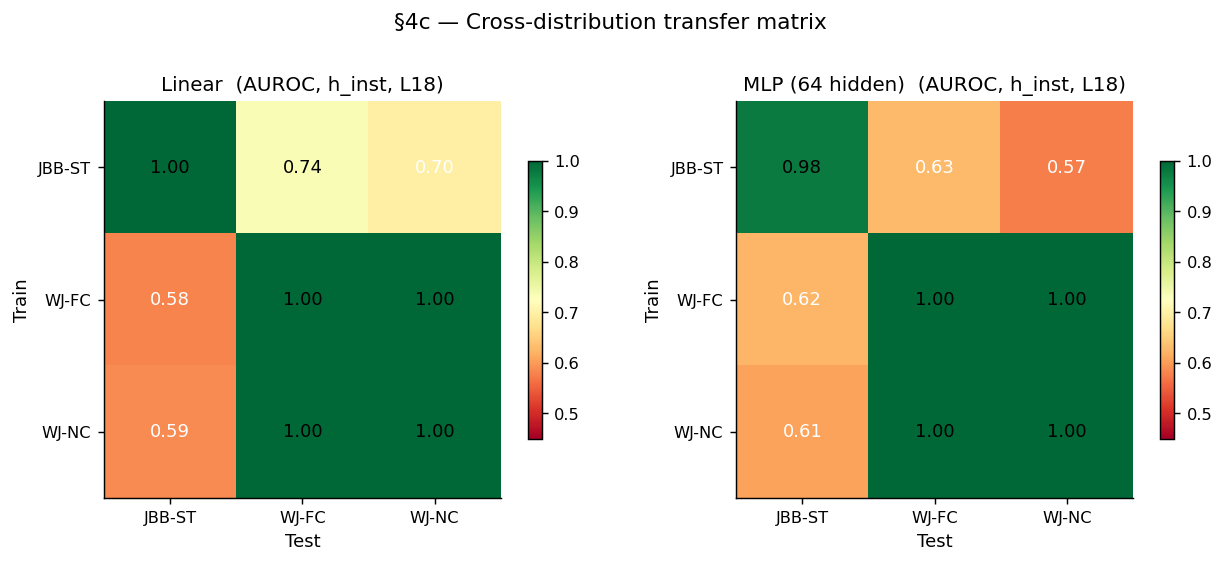

JBB-ST → WJ-FC: linear=0.735  MLP=0.630  gap=-0.106
  → MLP < linear: MLP overfit / artifact.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in zip(axes, [mat_lin, mat_mlp], ["Linear", "MLP (64 hidden)"]):
    im = ax.imshow(mat, cmap="RdYlGn", vmin=0.45, vmax=1.0)
    for i in range(len(SPECS)):
        for j in range(len(SPECS)):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v < 0.7 else "black", fontsize=10)
    ax.set_xticks(range(len(SPECS))); ax.set_xticklabels(SPECS)
    ax.set_yticks(range(len(SPECS))); ax.set_yticklabels(SPECS)
    ax.set_xlabel("Test")
    ax.set_ylabel("Train")
    ax.set_title(f"{title}  (AUROC, h_inst, {LAYER_LABELS[HEADLINE_LAYER_POS]})")
    plt.colorbar(im, ax=ax, shrink=0.7)

fig.suptitle("§4c — Cross-distribution transfer matrix", y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_fig4_linearity_transfer.png")
plt.show()

# Diagnostic cell: JBB-ST → WJ-FC
i_tr = SPECS.index("JBB-ST"); j_te = SPECS.index("WJ-FC")
v_lin = mat_lin[i_tr, j_te]; v_mlp = mat_mlp[i_tr, j_te]
gap = v_mlp - v_lin
print(f"JBB-ST → WJ-FC: linear={v_lin:.3f}  MLP={v_mlp:.3f}  gap={gap:+.3f}")
if not np.isnan(gap):
    if abs(gap) < 0.05:
        print("  → MLP no better than linear: structural rotation (H2b-WJ supported).")
    elif gap > 0.05:
        print("  → MLP > linear: rotation is partially linear-recoverable (H2b-WJ weakened).")
    else:
        print("  → MLP < linear: MLP overfit / artifact.")

### 4d. RQ3 — Position role collapse on WJ Crescendo

**Hypothesis (H3-WJ).** Zhao et al.'s clean separation — t_inst encodes
harmfulness, t_post encodes refusal — collapses on multi-turn WJ exactly as
it does on multi-turn JBB (§5 of nb05). Both positions perform similarly
on both tasks; the functional separation is a single-turn artifact of how
self-attention organizes one isolated instruction.

**Method.** Two AUROC tasks at every layer for each position (final turn,
test split):
- **Harmfulness:** harmful vs benign goal_type.
- **Refusal:** AISI-refused vs AISI-jailbroken within harmful only.

If H3 holds: t_inst and t_post lines should be interleaved on both tasks,
not separated by position role.

In [21]:
def position_specificity_curves():
    if ("trajectories", "harmful") not in wj_mt or ("trajectories", "benign") not in wj_mt:
        return None
    d_h = wj_mt[("trajectories", "harmful")]; d_b = wj_mt[("trajectories", "benign")]
    ft_h = get_final_turn_idx(d_h); ft_b = get_final_turn_idx(d_b)
    m_fh = d_h["meta"].iloc[ft_h]; m_fb = d_b["meta"].iloc[ft_b]
    test_h = (m_fh["data_split"] == "test").values
    test_b = (m_fb["data_split"] == "test").values

    # Harmfulness task — uses goal_type
    out = {"harmfulness": {"h_inst": [], "h_post": []},
           "refusal":     {"h_inst": [], "h_post": []}}
    for li in range(N_LAYERS_SAVED):
        for h_key in ["h_inst", "h_post"]:
            H = np.concatenate([d_h[h_key][ft_h[test_h], li, :],
                                d_b[h_key][ft_b[test_b], li, :]], axis=0).astype(np.float32)
            y = np.concatenate([np.ones(test_h.sum()), np.zeros(test_b.sum())])
            v = v_st_jbb[h_key][li]
            proj = H @ v
            out["harmfulness"][h_key].append(roc_auc_score(y, proj))

            # Refusal: within harmful only, label = aisi_jailbroken on harmful
            mh = m_fh[test_h]
            if "aisi_jailbroken" not in mh.columns or mh["aisi_jailbroken"].isna().all():
                out["refusal"][h_key].append(np.nan)
                continue
            mask = mh["aisi_jailbroken"].notna().values
            if mask.sum() < 30:
                out["refusal"][h_key].append(np.nan); continue
            H_r = d_h[h_key][ft_h[test_h][mask], li, :].astype(np.float32)
            # Refusal direction: refused (jailbroken=False, harmful) vs accepted (jailbroken=True, harmful)
            # Use within-train direction at h_post for refusal, but here we score with v_st_jbb
            # because we're measuring whether v_st_jbb (a *harmfulness* direction) discriminates refusal.
            # If t_post specifically encodes refusal, this projection should NOT do so —
            # but a refusal-specific classifier should. We instead train a per-position refusal direction
            # on TRAIN and evaluate on TEST.
            # Train: harmful, train split, attached aisi
            train_h_mask = (m_fh["data_split"] == "train").values
            mh_tr = m_fh[train_h_mask]
            if "aisi_jailbroken" not in mh_tr.columns or mh_tr["aisi_jailbroken"].isna().all():
                out["refusal"][h_key].append(np.nan); continue
            ok_tr = mh_tr["aisi_jailbroken"].notna().values
            if ok_tr.sum() < 30:
                out["refusal"][h_key].append(np.nan); continue
            H_tr = d_h[h_key][ft_h[train_h_mask][ok_tr], li, :].astype(np.float32)
            y_tr = (~mh_tr["aisi_jailbroken"].astype(bool)).values[ok_tr].astype(int)  # 1 = refused
            mu_ref = H_tr[y_tr == 1].mean(axis=0)
            mu_acc = H_tr[y_tr == 0].mean(axis=0)
            if (y_tr == 1).sum() < 5 or (y_tr == 0).sum() < 5:
                out["refusal"][h_key].append(np.nan); continue
            v_ref = mu_ref - mu_acc
            v_ref = v_ref / (np.linalg.norm(v_ref) + 1e-12)
            y_te = (~mh.iloc[mask]["aisi_jailbroken"].astype(bool)).values.astype(int)
            if y_te.sum() < 3 or (1 - y_te).sum() < 3:
                out["refusal"][h_key].append(np.nan); continue
            proj_r = H_r @ v_ref
            out["refusal"][h_key].append(roc_auc_score(y_te, proj_r))
    return out


pos_curves = position_specificity_curves()

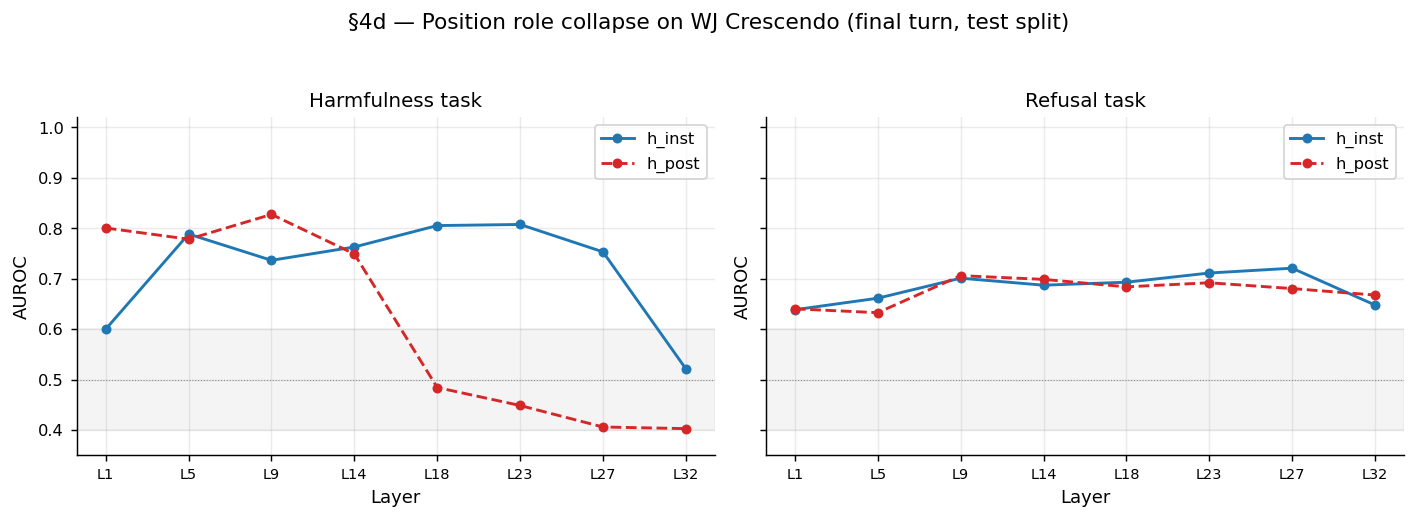

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
xs = np.arange(N_LAYERS_SAVED)
if pos_curves is not None:
    for ax, task in zip(axes, ["harmfulness", "refusal"]):
        for h_key, color, ls in [("h_inst", PALETTE["h_inst"], "-"),
                                  ("h_post", PALETTE["h_post"], "--")]:
            y = pos_curves[task][h_key]
            ax.plot(xs, y, ls + "o", color=color, lw=1.6, ms=4.5, label=h_key)
        ax.axhline(0.5, color="#888", lw=0.6, ls=":")
        ax.axhspan(0.4, 0.6, color="#cccccc", alpha=0.2)
        ax.set_xticks(xs); ax.set_xticklabels(LAYER_LABELS, fontsize=8)
        ax.set_xlabel("Layer")
        ax.set_ylabel("AUROC")
        ax.set_title(f"{task.capitalize()} task")
        ax.set_ylim(0.35, 1.02)
        ax.grid(True, alpha=0.25)
        ax.legend()
fig.suptitle("§4d — Position role collapse on WJ Crescendo (final turn, test split)", y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_fig5_position_collapse.png")
plt.show()

### 4e. RQ4 — Locus of harmfulness signal on WJ (Zhao 3-cell on OOD)

**Hypothesis (H4-WJ).** In full-context, refused-harmful WJ conversations
sit in the JBB-defined "harmful" cluster (s^l > 0); strip the context and
the signal collapses (H4b — context carries the recognition).

**Method.** Cluster centers from JBB single-turn:
- μ_refused-harmful ← mean(JBB-ST harmful)
- μ_accepted-harmless ← mean(JBB-ST benign)

Score WJ-Crescendo-final-turn rows with Zhao Eq. 2:

s^l(h^l) = cos(h^l, μ_refused-harmful) − cos(h^l, μ_accepted-harmless)

at every layer, with three groups (AISI-derived):
- accepted_harmful: harmful split + AISI jailbroken
- refused_harmful: harmful split + AISI not jailbroken
- accepted_harmless: benign split

Compare full-context vs no-context. The full ↔ no-context gap is the H4b test.

In [23]:
def cos_to(mu, H):
    """cosine sim between vector mu (D,) and rows of H (N, D)."""
    mu_n = mu / (np.linalg.norm(mu) + 1e-12)
    H_n  = H / (np.linalg.norm(H, axis=1, keepdims=True) + 1e-12)
    return H_n @ mu_n


# JBB cluster centers per layer per position
mu_clean = {}
for h_key in ["h_inst", "h_post"]:
    Hh = jbb_st["harmful"][h_key]
    Hb = jbb_st["benign" ][h_key]
    for li in range(N_LAYERS_SAVED):
        mu_rh = Hh[:, li, :].astype(np.float32).mean(axis=0)
        mu_ah = Hb[:, li, :].astype(np.float32).mean(axis=0)
        mu_clean[(h_key, li)] = (mu_rh, mu_ah)


def s_curves(cond):
    """Mean s^l per layer per group, h_inst and h_post."""
    if (cond, "harmful") not in wj_mt or (cond, "benign") not in wj_mt:
        return None
    d_h = wj_mt[(cond, "harmful")]; d_b = wj_mt[(cond, "benign")]
    ft_h = get_final_turn_idx(d_h); ft_b = get_final_turn_idx(d_b)
    m_fh = d_h["meta"].iloc[ft_h]; m_fb = d_b["meta"].iloc[ft_b]
    test_h = (m_fh["data_split"] == "test").values
    test_b = (m_fb["data_split"] == "test").values
    if "aisi_jailbroken" not in m_fh.columns:
        return None

    out = {h: {g: np.full(N_LAYERS_SAVED, np.nan) for g in ["accepted_harmful", "refused_harmful", "accepted_harmless"]}
           for h in ["h_inst", "h_post"]}
    for h_key in ["h_inst", "h_post"]:
        for li in range(N_LAYERS_SAVED):
            mu_rh, mu_ah = mu_clean[(h_key, li)]

            mh = m_fh[test_h]
            ok = mh["aisi_jailbroken"].notna()
            if ok.sum() == 0:
                continue
            jail = mh.loc[ok, "aisi_jailbroken"].astype(bool).values

            H_h = d_h[h_key][ft_h[test_h][ok.values], li, :].astype(np.float32)
            if jail.sum() >= 3:
                s = cos_to(mu_rh, H_h[jail]) - cos_to(mu_ah, H_h[jail])
                out[h_key]["accepted_harmful"][li] = s.mean()
            if (~jail).sum() >= 3:
                s = cos_to(mu_rh, H_h[~jail]) - cos_to(mu_ah, H_h[~jail])
                out[h_key]["refused_harmful"][li] = s.mean()

            H_b = d_b[h_key][ft_b[test_b], li, :].astype(np.float32)
            if len(H_b) >= 3:
                s = cos_to(mu_rh, H_b) - cos_to(mu_ah, H_b)
                out[h_key]["accepted_harmless"][li] = s.mean()
    return out


s_full = s_curves("trajectories")
s_nc   = s_curves("nocontext")

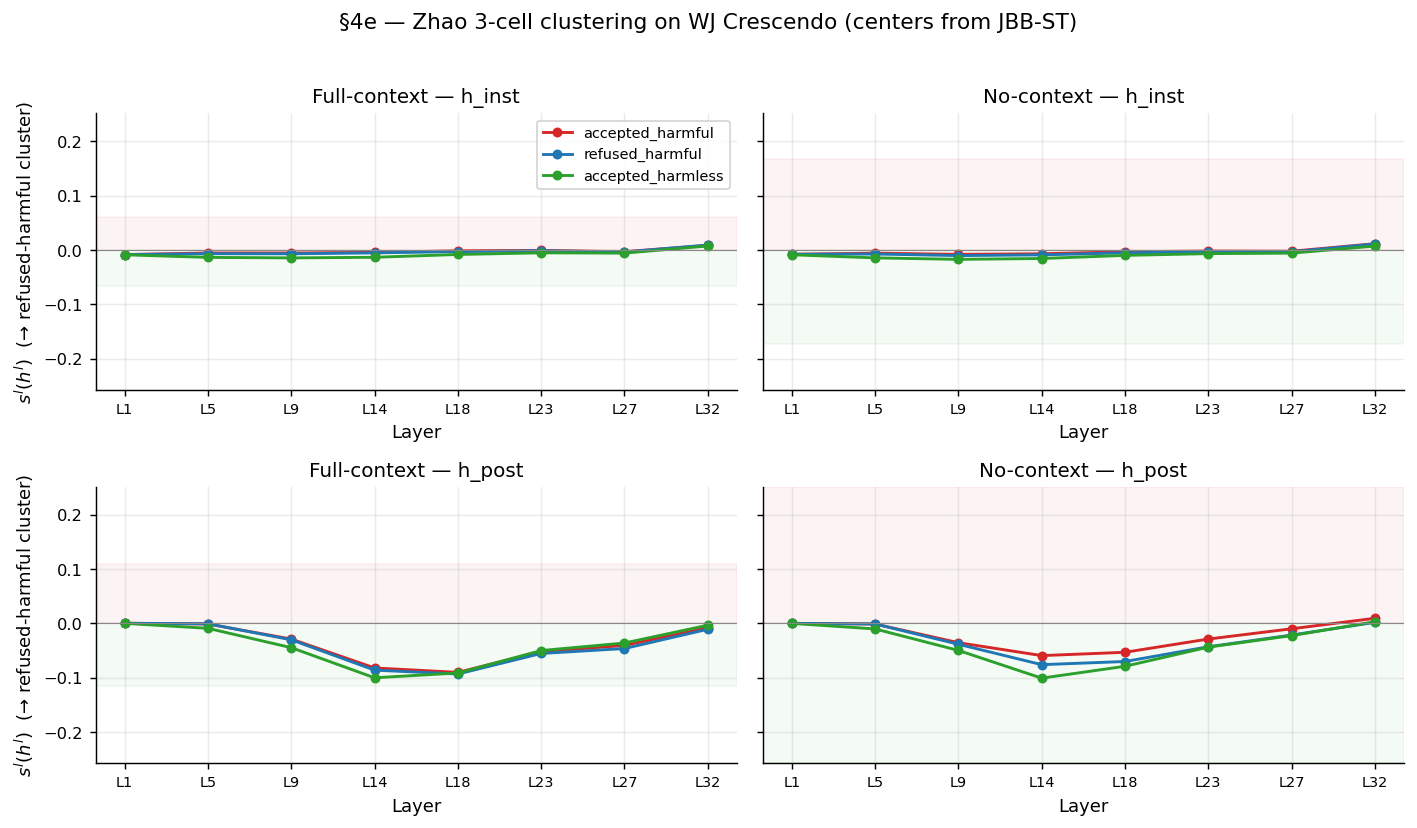

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.2), sharey=True)
xs = np.arange(N_LAYERS_SAVED)

for col, (cond_name, curves) in enumerate([("Full-context", s_full), ("No-context", s_nc)]):
    for row, h_key in enumerate(["h_inst", "h_post"]):
        ax = axes[row, col]
        if curves is not None:
            for g in ["accepted_harmful", "refused_harmful", "accepted_harmless"]:
                ax.plot(xs, curves[h_key][g], "o-", color=PALETTE[g], lw=1.6, ms=4.5,
                        label=g)
            # Pad y-axis 25% beyond data so markers/lines aren't clipped
            y0_data, y1_data = ax.get_ylim()
            span = y1_data - y0_data
            pad = max(0.05, 0.25 * span)
            y0, y1 = y0_data - pad, y1_data + pad
            if y1 > 0:
                ax.axhspan(0, y1, color="#d62728", alpha=0.05, zorder=0)
            if y0 < 0:
                ax.axhspan(y0, 0, color="#2ca02c", alpha=0.05, zorder=0)
            ax.set_ylim(y0, y1)
        ax.axhline(0, color="#888", lw=0.6)
        ax.set_xticks(xs); ax.set_xticklabels(LAYER_LABELS, fontsize=8)
        ax.set_xlabel("Layer")
        ax.set_ylabel(r"$s^l(h^l)$  (→ refused-harmful cluster)" if col == 0 else "")
        ax.set_title(f"{cond_name} — {h_key}")
        ax.grid(True, alpha=0.25)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc="best")

fig.suptitle("§4e — Zhao 3-cell clustering on WJ Crescendo (centers from JBB-ST)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_fig6_zhao_3cell_wj.png")
plt.show()

## 5. Cross-tier consolidation

A single table that the WJ section of the paper can cite directly. Each
row is a hypothesis with its pre-declared falsification threshold and the
observed result with bootstrap CI.

In [25]:
summary = []
# Tier 1
if (vc := tier_curves.get(("vanilla", "h_inst"))) is not None:
    m, lo, hi = vc; b = int(np.nanargmax(m))
    summary.append({"hyp": "Tier 1", "threshold": f">= {TIER1_AUROC_FLOOR}",
                    "value": f"{m[b]:.3f} [{lo[b]:.3f}, {hi[b]:.3f}] @ {LAYER_LABELS[b]}",
                    "pass": "PASS" if m[b] >= TIER1_AUROC_FLOOR else "FAIL"})
# Tier 2
if (vc := tier_curves.get(("adversarial", "h_inst"))) is not None:
    m, lo, hi = vc; b = int(np.nanargmax(m))
    summary.append({"hyp": "Tier 2", "threshold": f">= {TIER2_AUROC_FLOOR}",
                    "value": f"{m[b]:.3f} [{lo[b]:.3f}, {hi[b]:.3f}] @ {LAYER_LABELS[b]}",
                    "pass": "PASS" if m[b] >= TIER2_AUROC_FLOOR else "FAIL"})
# H1 displacement
if EL_TURNS:
    boot = bootstrap_displacement_endpoint(HEADLINE_LAYER_POS, "h_inst", EL_TURNS[-1])
    if boot is not None:
        mean, lo, hi = boot
        summary.append({"hyp": "H1-WJ displacement",
                        "threshold": f"CI on cos(k_max) excludes {DISPLACEMENT_CI_BOUND}",
                        "value": f"{mean:.3f} [{lo:.3f}, {hi:.3f}]",
                        "pass": "PASS" if hi < DISPLACEMENT_CI_BOUND else "FAIL"})
# H2a detection
if not det_df.empty:
    fix_avg = det_df["fixed_mean"].mean(); adp_avg = det_df["adp_mean"].mean()
    summary.append({"hyp": "H2a-WJ detection-failure",
                    "threshold": "fixed < 0.65 and adaptive > 0.75",
                    "value": f"fixed={fix_avg:.3f}  adaptive={adp_avg:.3f}",
                    "pass": "PASS" if (fix_avg < 0.65 and adp_avg > 0.75) else "FAIL"})
# H2b linearity
i_tr = SPECS.index("JBB-ST"); j_te = SPECS.index("WJ-FC")
gap_ml = mat_mlp[i_tr, j_te] - mat_lin[i_tr, j_te]
if not np.isnan(gap_ml):
    summary.append({"hyp": "H2b-WJ structural rotation",
                    "threshold": "MLP - linear gap < 0.05 (no nonlinear escape)",
                    "value": f"linear={mat_lin[i_tr,j_te]:.3f}  MLP={mat_mlp[i_tr,j_te]:.3f}  gap={gap_ml:+.3f}",
                    "pass": "PASS" if abs(gap_ml) < 0.05 else "FAIL"})

print(pd.DataFrame(summary).to_string(index=False))

                       hyp                                     threshold                               value pass
        H1-WJ displacement                 CI on cos(k_max) excludes 0.5                0.090 [0.044, 0.135] PASS
  H2a-WJ detection-failure              fixed < 0.65 and adaptive > 0.75         fixed=0.636  adaptive=0.904 PASS
H2b-WJ structural rotation MLP - linear gap < 0.05 (no nonlinear escape) linear=0.735  MLP=0.630  gap=-0.106 FAIL


## 6. Limitations

1. **Single model, single framework.** Llama-3.1-8B + Crescendo only. The
   WJ generalization claim becomes paper-strength only after the same
   notebook runs on Gemma and Qwen, and on the other two frameworks if
   their WJ data is generated. Cross-model consolidation is a separate
   notebook.

2. **AISI scoring is itself a judge.** AISI-StrongREJECT is independent of
   the framework attacker but still an LM judge. Rare label flips at the
   threshold boundary are possible; a 3 vs 2 raw-rubric split is sometimes
   debatable.

3. **WJ vanilla is moderation-pre-filtered.** The 50 OOD harmful goals come
   from the pool that scored ≥ 0.7 on `omni-moderation-latest` (see nb07).
   This shifts category mix away from JBB's 10 categories — `illicit`
   dominates. If the harmfulness direction is category-specific, the
   numbers above mix transfer-to-OOD-distribution with category-shift.

4. **Sample-size floor at late k.** WJ has 50 goals × 20 attempts = 1000
   harmful conversations. Crescendo's average length means n_test at k=8+
   may dip below the n ≥ 100 floor; those turns are excluded from primary
   plots.

5. **Position role analysis is correlational.** The §4d AUROC numbers
   show the positions don't *separate* harmfulness and refusal in
   multi-turn, but cannot prove they don't *encode* them in some entangled
   form recoverable by a more sophisticated decoder. The causal test
   (Zhao's reply-inversion) is not run on WJ.

6. **MLP capacity choice is fixed.** §4c uses (64,) hidden-units, the
   Bullwinkel default. Larger MLPs might recover more of the JBB-ST → WJ-FC
   transfer; the structural-rotation claim is conditional on this capacity.